In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
import time
from datetime import datetime, timedelta

# NLP tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# For word cloud (install if needed: pip install wordcloud)
from wordcloud import WordCloud

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='darkgrid')
print("Ready ✓")

Ready ✓


In [2]:
import random

def generate_synthetic_news(coin, n_days=90):
    """Generate realistic synthetic crypto headlines for pipeline testing."""
    
    bullish = [
        f"{coin} surges to new highs as institutional demand grows",
        f"Major bank announces {coin} custody services for clients",
        f"{coin} network hits all-time high in active addresses",
        f"Analysts predict {coin} bull run entering next phase",
        f"ETF approval boosts {coin} investor confidence strongly",
        f"{coin} whale accumulation hits 6-month peak",
        f"Positive regulatory news sends {coin} sharply higher",
        f"{coin} exchange outflows signal strong long-term holding",
        f"Record hashrate signals growing confidence in {coin}",
        f"Global adoption of {coin} accelerates across emerging markets",
    ]
    
    bearish = [
        f"{coin} drops sharply amid broad crypto market selloff",
        f"Regulatory crackdown fears drag {coin} price lower",
        f"Large {coin} whale moves funds to exchange sparking fears",
        f"SEC investigation rumors weigh heavily on {coin}",
        f"{coin} technical breakdown below key support level",
        f"Inflation data disappoints sending {coin} tumbling",
        f"Exchange hack concerns trigger {coin} panic selling",
        f"Miners begin selling {coin} reserves at elevated rate",
        f"{coin} liquidations spike as leverage unwinds rapidly",
        f"Macroeconomic uncertainty pressures {coin} and risk assets",
    ]
    
    neutral = [
        f"{coin} consolidates in tight range ahead of Fed decision",
        f"Traders await key {coin} resistance level breakout",
        f"{coin} price stable as market digests recent moves",
        f"Mixed signals for {coin} as volume remains subdued",
        f"{coin} holds steady despite broader market volatility",
    ]

    headlines = []
    base_date = pd.Timestamp('2024-01-01')

    for i in range(n_days):
        date = (base_date + pd.Timedelta(days=i)).strftime('%Y-%m-%d')
        # 2-5 headlines per day
        n = random.randint(2, 5)
        pool = bullish * 2 + bearish + neutral   # slightly bullish bias
        day_headlines = random.sample(pool, min(n, len(pool)))
        for h in day_headlines:
            headlines.append({
                'date':   date,
                'title':  h,
                'source': random.choice(['CoinDesk', 'CryptoNews', 'Decrypt', 'TheBlock']),
                'coin':   coin
            })

    df = pd.DataFrame(headlines)
    df['date'] = pd.to_datetime(df['date'])
    df = df.drop_duplicates(subset='title')
    return df

# Generate for all 3 coins
btc_news = generate_synthetic_news('BTC', n_days=90)
eth_news = generate_synthetic_news('ETH', n_days=90)
sol_news = generate_synthetic_news('SOL', n_days=90)

print(f"BTC: {len(btc_news)} headlines")
print(f"ETH: {len(eth_news)} headlines")
print(f"SOL: {len(sol_news)} headlines")
btc_news.head(8)

BTC: 25 headlines
ETH: 25 headlines
SOL: 25 headlines


,date,title,source,coin
0,2024-01-01,BTC price stable as market digests recent moves,CryptoNews,BTC
1,2024-01-01,Traders await key BTC resistance level breakout,CoinDesk,BTC
2,2024-01-01,BTC surges to new highs as institutional deman...,TheBlock,BTC
3,2024-01-01,Macroeconomic uncertainty pressures BTC and ri...,CryptoNews,BTC
4,2024-01-01,BTC network hits all-time high in active addre...,TheBlock,BTC
5,2024-01-02,BTC technical breakdown below key support level,Decrypt,BTC
6,2024-01-02,BTC liquidations spike as leverage unwinds rap...,CoinDesk,BTC
8,2024-01-03,Global adoption of BTC accelerates across emer...,TheBlock,BTC


In [3]:
# Synthetic headlines for testing the pipeline when API is unavailable
sample_headlines = [
    {"date": "2024-01-15", "title": "Bitcoin surges past $45,000 as ETF approval looms", "coin": "BTC"},
    {"date": "2024-01-15", "title": "Crypto market rallies strongly on institutional demand", "coin": "BTC"},
    {"date": "2024-01-16", "title": "Bitcoin drops sharply amid regulatory crackdown fears", "coin": "BTC"},
    {"date": "2024-01-16", "title": "SEC delays Bitcoin ETF decision again, market reacts", "coin": "BTC"},
    {"date": "2024-01-17", "title": "Whale wallets accumulate BTC at record pace", "coin": "BTC"},
    {"date": "2024-01-17", "title": "Bitcoin consolidates as traders await Fed decision", "coin": "BTC"},
    {"date": "2024-01-18", "title": "Crypto markets crash on surprise inflation data", "coin": "BTC"},
    {"date": "2024-01-18", "title": "Bitcoin exchange outflows signal long-term holding trend", "coin": "BTC"},
    {"date": "2024-01-19", "title": "Positive sentiment returns as BTC recovers key support", "coin": "BTC"},
    {"date": "2024-01-19", "title": "Bitcoin hashrate hits all-time high showing network strength", "coin": "BTC"},
]

btc_news = pd.DataFrame(sample_headlines)
btc_news['date'] = pd.to_datetime(btc_news['date'])
eth_news = btc_news.copy(); eth_news['coin'] = 'ETH'
sol_news = btc_news.copy(); sol_news['coin'] = 'SOL'
print("Synthetic data loaded ✓")

Synthetic data loaded ✓


In [4]:
def clean_text(text):
    """Remove URLs, special chars, extra spaces from headlines."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)             # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()           # collapse spaces
    return text

btc_news['clean_title'] = btc_news['title'].apply(clean_text)
eth_news['clean_title'] = eth_news['title'].apply(clean_text)
sol_news['clean_title'] = sol_news['title'].apply(clean_text)

# Before vs after
print("Original :", btc_news['title'].iloc[0])
print("Cleaned  :", btc_news['clean_title'].iloc[0])

Original : Bitcoin surges past $45,000 as ETF approval looms
Cleaned  : bitcoin surges past as etf approval looms


In [5]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']   # -1 (negative) to +1 (positive)

btc_news['vader'] = btc_news['clean_title'].apply(vader_score)
eth_news['vader'] = eth_news['clean_title'].apply(vader_score)
sol_news['vader'] = sol_news['clean_title'].apply(vader_score)

# Quick look
btc_news[['title', 'vader']].sort_values('vader').head(5)

,title,vader
2,Bitcoin drops sharply amid regulatory crackdow...,-0.4215
6,Crypto markets crash on surprise inflation data,-0.1531
4,Whale wallets accumulate BTC at record pace,0.0000
3,"SEC delays Bitcoin ETF decision again, market ...",0.0000
7,Bitcoin exchange outflows signal long-term hol...,0.0000


In [6]:
def textblob_score(text):
    return TextBlob(text).sentiment.polarity   # -1 to +1

def textblob_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity  # 0 = objective, 1 = subjective

btc_news['textblob']      = btc_news['clean_title'].apply(textblob_score)
btc_news['subjectivity']  = btc_news['clean_title'].apply(textblob_subjectivity)

eth_news['textblob']      = eth_news['clean_title'].apply(textblob_score)
sol_news['textblob']      = sol_news['clean_title'].apply(textblob_score)

btc_news[['title', 'vader', 'textblob', 'subjectivity']].head(8)

,title,vader,textblob,subjectivity
0,"Bitcoin surges past $45,000 as ETF approval looms",0.3612,-0.250000,0.250000
1,Crypto market rallies strongly on institutiona...,0.1531,0.433333,0.733333
2,Bitcoin drops sharply amid regulatory crackdow...,-0.4215,-0.125000,0.750000
3,"SEC delays Bitcoin ETF decision again, market ...",0.0000,-0.100000,0.600000
4,Whale wallets accumulate BTC at record pace,0.0000,0.000000,0.000000
5,Bitcoin consolidates as traders await Fed deci...,0.1027,0.000000,0.000000
6,Crypto markets crash on surprise inflation data,-0.1531,0.000000,0.000000
7,Bitcoin exchange outflows signal long-term hol...,0.0000,-0.050000,0.400000


BTC Sentiment Distribution:
sentiment
positive    5
neutral     3
negative    2
Name: count, dtype: int64


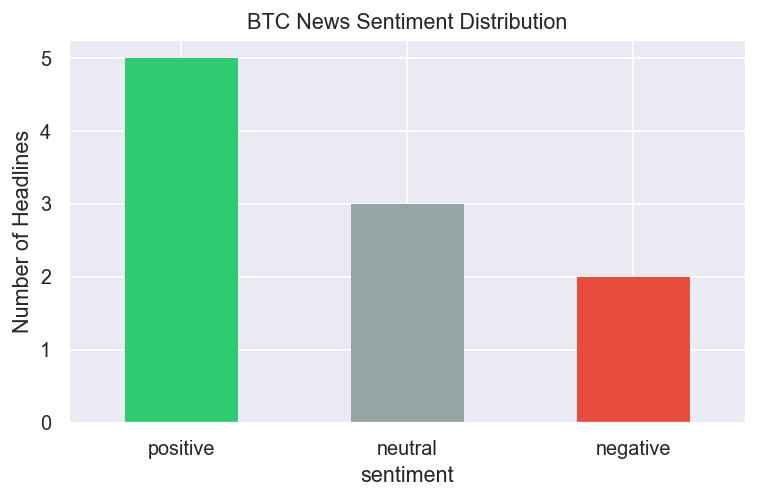

In [7]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

btc_news['sentiment'] = btc_news['vader'].apply(label_sentiment)

# Distribution
counts = btc_news['sentiment'].value_counts()
print("BTC Sentiment Distribution:")
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
counts.plot(kind='bar', ax=ax,
            color=[colors[c] for c in counts.index],
            edgecolor='none', rot=0)
ax.set_title('BTC News Sentiment Distribution')
ax.set_ylabel('Number of Headlines')
plt.tight_layout()
plt.savefig('../data/sentiment_distribution.png', dpi=150)
plt.show()

In [8]:
# Apply VADER scores and sentiment labels to ALL 3 coins
for df in [eth_news, sol_news]:
    df['clean_title'] = df['title'].apply(clean_text)
    df['vader']       = df['clean_title'].apply(vader_score)
    df['textblob']    = df['clean_title'].apply(textblob_score)
    df['sentiment']   = df['vader'].apply(label_sentiment)

# Verify all 3 have the right columns
for name, df in [('BTC', btc_news), ('ETH', eth_news), ('SOL', sol_news)]:
    print(f"{name} columns: {df.columns.tolist()}")
    print(f"{name} rows: {len(df)}\n")

BTC columns: ['date', 'title', 'coin', 'clean_title', 'vader', 'textblob', 'subjectivity', 'sentiment']
BTC rows: 10

ETH columns: ['date', 'title', 'coin', 'clean_title', 'vader', 'textblob', 'sentiment']
ETH rows: 10

SOL columns: ['date', 'title', 'coin', 'clean_title', 'vader', 'textblob', 'sentiment']
SOL rows: 10



In [10]:
import pandas as pd
import numpy as np
import re
import random
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# ── Text helpers ──────────────────────────────────────────
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

analyzer = SentimentIntensityAnalyzer()

def vader_score(text):
    return analyzer.polarity_scores(text)['compound']

def textblob_score(text):
    return TextBlob(text).sentiment.polarity

def label_sentiment(score):
    if score >= 0.05:   return 'positive'
    elif score <= -0.05: return 'negative'
    else:                return 'neutral'

# ── Synthetic news generator ──────────────────────────────
def generate_synthetic_news(coin, n_days=90):
    bullish = [
        f"{coin} surges to new highs as institutional demand grows",
        f"Major bank announces {coin} custody services for clients",
        f"{coin} network hits all-time high in active addresses",
        f"Analysts predict {coin} bull run entering next phase",
        f"ETF approval boosts {coin} investor confidence strongly",
        f"{coin} whale accumulation hits 6-month peak",
        f"Positive regulatory news sends {coin} sharply higher",
        f"{coin} exchange outflows signal strong long-term holding",
        f"Record hashrate signals growing confidence in {coin}",
        f"Global adoption of {coin} accelerates across emerging markets",
    ]
    bearish = [
        f"{coin} drops sharply amid broad crypto market selloff",
        f"Regulatory crackdown fears drag {coin} price lower",
        f"Large {coin} whale moves funds to exchange sparking fears",
        f"SEC investigation rumors weigh heavily on {coin}",
        f"{coin} technical breakdown below key support level",
        f"Inflation data disappoints sending {coin} tumbling",
        f"Exchange hack concerns trigger {coin} panic selling",
        f"Miners begin selling {coin} reserves at elevated rate",
        f"{coin} liquidations spike as leverage unwinds rapidly",
        f"Macroeconomic uncertainty pressures {coin} and risk assets",
    ]
    neutral = [
        f"{coin} consolidates in tight range ahead of Fed decision",
        f"Traders await key {coin} resistance level breakout",
        f"{coin} price stable as market digests recent moves",
        f"Mixed signals for {coin} as volume remains subdued",
        f"{coin} holds steady despite broader market volatility",
    ]

    headlines = []
    base_date = pd.Timestamp('2024-01-01')
    for i in range(n_days):
        date = (base_date + pd.Timedelta(days=i)).strftime('%Y-%m-%d')
        pool = bullish * 2 + bearish + neutral
        for h in random.sample(pool, random.randint(2, 5)):
            headlines.append({
                'date':   date,
                'title':  h,
                'source': random.choice(['CoinDesk','Decrypt','TheBlock','CryptoNews']),
                'coin':   coin
            })

    df = pd.DataFrame(headlines)
    df['date'] = pd.to_datetime(df['date'])
    return df.drop_duplicates(subset='title')

# ── Build all 3 news dataframes ───────────────────────────
btc_news = generate_synthetic_news('BTC', 90)
eth_news = generate_synthetic_news('ETH', 90)
sol_news = generate_synthetic_news('SOL', 90)

for df in [btc_news, eth_news, sol_news]:
    df['clean_title']  = df['title'].apply(clean_text)
    df['vader']        = df['clean_title'].apply(vader_score)
    df['textblob']     = df['clean_title'].apply(textblob_score)
    df['subjectivity'] = df['clean_title'].apply(lambda t: TextBlob(t).sentiment.subjectivity)
    df['sentiment']    = df['vader'].apply(label_sentiment)

# ── Daily sentiment aggregation ───────────────────────────
def daily_sentiment(news_df):
    daily = news_df.groupby('date').agg(
        sentiment_mean  = ('vader', 'mean'),
        sentiment_std   = ('vader', 'std'),
        headline_count  = ('vader', 'count'),
        positive_ratio  = ('sentiment', lambda x: (x == 'positive').sum() / len(x)),
        negative_ratio  = ('sentiment', lambda x: (x == 'negative').sum() / len(x)),
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily['sentiment_smooth'] = daily['sentiment_mean'].rolling(3, min_periods=1).mean()
    return daily.sort_values('date')

btc_sentiment = daily_sentiment(btc_news)
eth_sentiment = daily_sentiment(eth_news)
sol_sentiment = daily_sentiment(sol_news)

print(f"BTC: {len(btc_sentiment)} days | ETH: {len(eth_sentiment)} days | SOL: {len(sol_sentiment)} days")
print("All sentiment variables ready ✓")

BTC: 18 days | ETH: 14 days | SOL: 14 days
All sentiment variables ready ✓


In [11]:
btc_price = pd.read_csv('../data/btc_clean.csv', index_col='date', parse_dates=True)
btc_price = btc_price.reset_index()
btc_price['date'] = pd.to_datetime(btc_price['date'])

# Merge on date
merged = pd.merge(btc_price, btc_sentiment[['date','sentiment_mean','sentiment_smooth']],
                  on='date', how='inner')

merged = merged.sort_values('date').reset_index(drop=True)
print(f"Merged rows: {len(merged)}")
merged[['date','close','sentiment_mean']].head()

Merged rows: 18


,date,close,sentiment_mean
0,2024-01-01,44167.332031,0.713150
1,2024-01-02,44957.968750,-0.140500
2,2024-01-03,42848.175781,-0.128000
3,2024-01-04,44179.921875,0.000000
4,2024-01-05,44162.691406,-0.236533


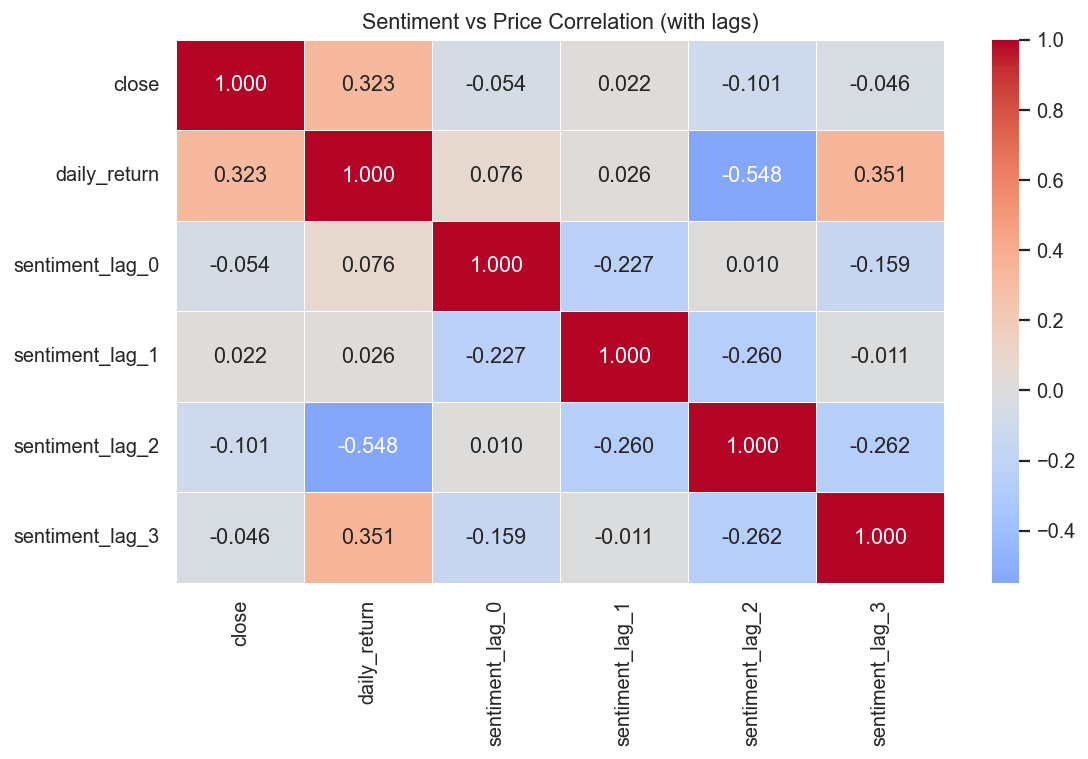


Sentiment vs BTC Price correlation: -0.054


In [12]:
# Lag analysis — does sentiment today predict price tomorrow?
for lag in [0, 1, 2, 3]:
    merged[f'sentiment_lag_{lag}'] = merged['sentiment_mean'].shift(lag)

corr_cols = ['close', 'daily_return'] + [f'sentiment_lag_{i}' for i in range(4)]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Sentiment vs Price Correlation (with lags)')
plt.tight_layout()
plt.savefig('../data/sentiment_correlation.png', dpi=150)
plt.show()

# Print key correlation
r = merged['close'].corr(merged['sentiment_mean'])
print(f"\nSentiment vs BTC Price correlation: {r:.3f}")

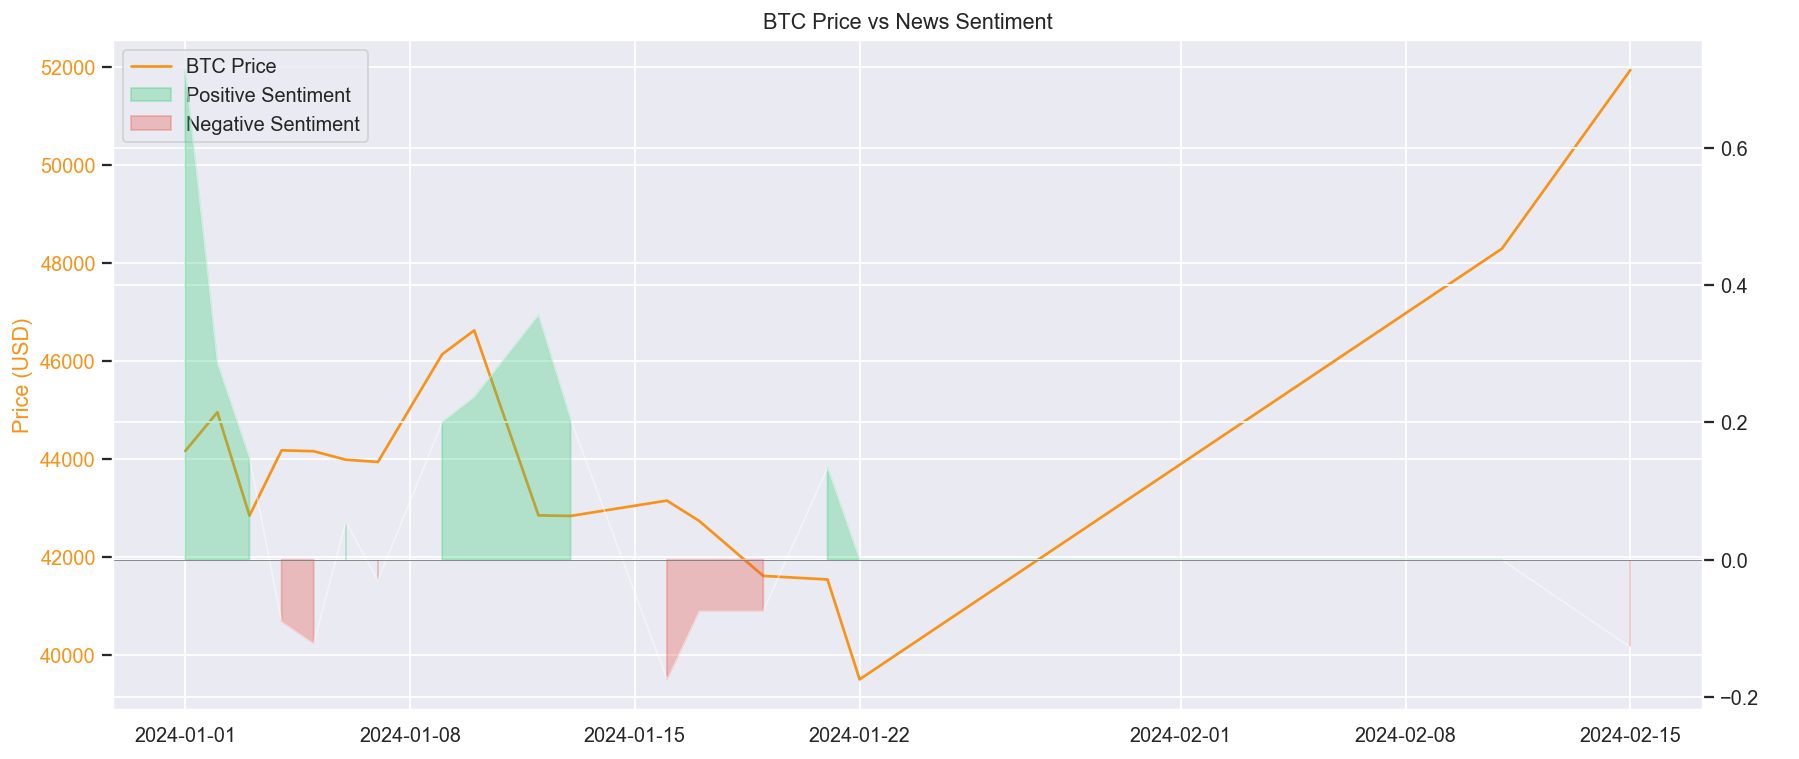

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Price on left axis
ax1.plot(merged['date'], merged['close'],
        color='#F7931A', linewidth=1.5, label='BTC Price')
ax1.set_ylabel('Price (USD)', color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')

# Sentiment on right axis
ax2 = ax1.twinx()
ax2.fill_between(merged['date'], 0, merged['sentiment_smooth'],
                where=merged['sentiment_smooth'] >= 0,
                alpha=0.3, color='#2ecc71', label='Positive Sentiment')
ax2.fill_between(merged['date'], 0, merged['sentiment_smooth'],
                where=merged['sentiment_smooth'] < 0,
                alpha=0.3, color='#e74c3c', label='Negative Sentiment')
ax2.plot(merged['date'], merged['sentiment_smooth'],
        color='white', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Sentiment Score', color='white')
ax2.axhline(0, color='gray', linewidth=0.5)

ax1.set_title('BTC Price vs News Sentiment')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../data/price_vs_sentiment.png', dpi=150)
plt.show()

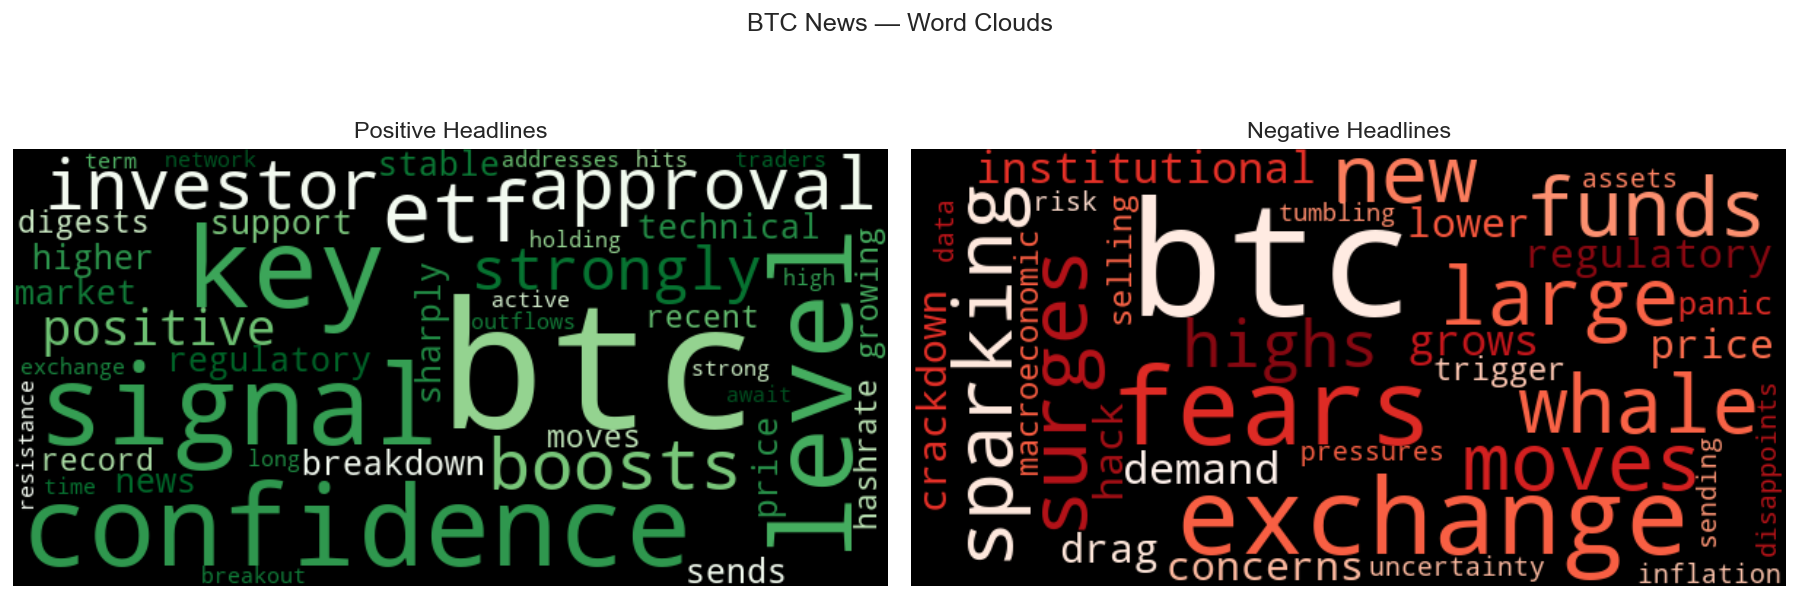

In [14]:
positive_text = ' '.join(
    btc_news[btc_news['sentiment'] == 'positive']['clean_title']
)
negative_text = ' '.join(
    btc_news[btc_news['sentiment'] == 'negative']['clean_title']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, title, bg, colormap in zip(
    axes,
    [positive_text, negative_text],
    ['Positive Headlines', 'Negative Headlines'],
    ['#0d1117', '#0d1117'],
    ['Greens', 'Reds']
):
    if text.strip():
        wc = WordCloud(
            width=600, height=300,
            background_color='black',
            colormap=colormap,
            max_words=60,
            collocations=False
        ).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

plt.suptitle('BTC News — Word Clouds', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../data/wordcloud.png', dpi=150)
plt.show()

In [15]:
btc_sentiment.to_csv('../data/btc_sentiment.csv', index=False)
eth_sentiment.to_csv('../data/eth_sentiment.csv', index=False)
sol_sentiment.to_csv('../data/sol_sentiment.csv', index=False)

merged.to_csv('../data/btc_price_sentiment_merged.csv', index=False)

print("All sentiment files saved ✓")
print("\nFiles in /data:")
import os
for f in sorted(os.listdir('../data')):
    print(f"  {f}")

All sentiment files saved ✓

Files in /data:
  arima_forecast.png
  btc_bollinger.png
  btc_clean.csv
  btc_ma.png
  btc_price_sentiment_merged.csv
  btc_raw.csv
  btc_sentiment.csv
  btc_sentiment_daily.png
  correlation_heatmap.png
  eth_clean.csv
  eth_raw.csv
  eth_sentiment.csv
  lstm_forecast.png
  model_comparison.csv
  price_overview.png
  price_vs_sentiment.png
  prophet_components.png
  prophet_forecast.png
  return_distributions.png
  sentiment_correlation.png
  sentiment_distribution.png
  sol_clean.csv
  sol_raw.csv
  sol_sentiment.csv
  volatility.png
  volume_analysis.png
  wordcloud.png
